# Getting rating curves from different streams in VCNP

Import data

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress

# discharge
lajara_2021 = pd.read_csv("../la_jara/shear_stress_2021.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # first column is datetime and second column is discharge in m3/s
lajara_2022 = pd.read_csv("../la_jara/shear_stress_2022.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # m3/s
lajara_2023 = pd.read_csv("../la_jara/shear_stress_2023.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # m3/s

redondo = pd.read_csv("../redondo/DataSetExport-Discharge.Discharge@VALL_MIRLKE-Maximum-ft^3 s-20260223140410.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
san_antonio = pd.read_csv("../san_antonio/DataSetExport-Discharge.Discharge@VALL_RSAWES-Maximum-ft^3 s-20260302191152.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
lower_sulphur = pd.read_csv("../lower_sulphur/DataSetExport-Discharge.Discharge (Daily Mean)@VALL_LWRSUL-Maximum-ft^3 s-20260302190628.csv", parse_dates=[0], index_col=0, na_values=['NaN']) 
upper_sulphur = pd.read_csv("../upper_sulphur/DataSetExport-Discharge.Discharge@VALL_UPRSUL-Maximum-ft^3 s-20260302181951.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
jemez = pd.read_csv("../jemez/jemez_stream_gauge.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft

In [83]:
# convert ft^3/s to m3/s for redondo, san_antonio, lower_sulphur, and upper_sulphur
redondo["redondo (m3/s)"] = redondo["Value (ft^3/s)"] * 0.0283168
san_antonio["san_antonio (m3/s)"] = san_antonio["Value (ft^3/s)"] * 0.0283168
lower_sulphur["lower_sulphur (m3/s)"] = lower_sulphur["Value (ft^3/s)"] * 0.0283168
upper_sulphur["upper_sulphur (m3/s)"] = upper_sulphur["Value (ft^3/s)"] * 0.0283168
jemez["jemez (ft)"] = jemez["value"] # keep jemez in ft for now

# la jara data as base 
lajara_2021.rename(columns={'0': 'la_jara'}, inplace=True)
lajara_2022.rename(columns={'0': 'la_jara'}, inplace=True)
lajara_2023.rename(columns={'0': 'la_jara'}, inplace=True)

In [84]:
# remove timezone info from all indices to enable joining
lajara_2021.index = lajara_2021.index.tz_localize(None) if lajara_2021.index.tz is not None else lajara_2021.index
lajara_2022.index = lajara_2022.index.tz_localize(None) if lajara_2022.index.tz is not None else lajara_2022.index
lajara_2023.index = lajara_2023.index.tz_localize(None) if lajara_2023.index.tz is not None else lajara_2023.index

redondo.index = redondo.index.tz_localize(None) if redondo.index.tz is not None else redondo.index
san_antonio.index = san_antonio.index.tz_localize(None) if san_antonio.index.tz is not None else san_antonio.index
lower_sulphur.index = lower_sulphur.index.tz_localize(None) if lower_sulphur.index.tz is not None else lower_sulphur.index
upper_sulphur.index = upper_sulphur.index.tz_localize(None) if upper_sulphur.index.tz is not None else upper_sulphur.index
jemez.index = jemez.index.tz_localize(None) if jemez.index.tz is not None else jemez.index

In [4]:
# keep data in each year starting from Aug 1 
#lajara_2021 = lajara_2021[(lajara_2021.index >= '2021-08-01')] #& (lajara_2021.index < '2021-12-01')]
#lajara_2022 = lajara_2022[(lajara_2022.index >= '2022-08-01')] #& (lajara_2022.index < '2022-12-01')]
#lajara_2023 = lajara_2023[(lajara_2023.index >= '2023-07-01')] #& (lajara_2023.index < '2023-12-01')]

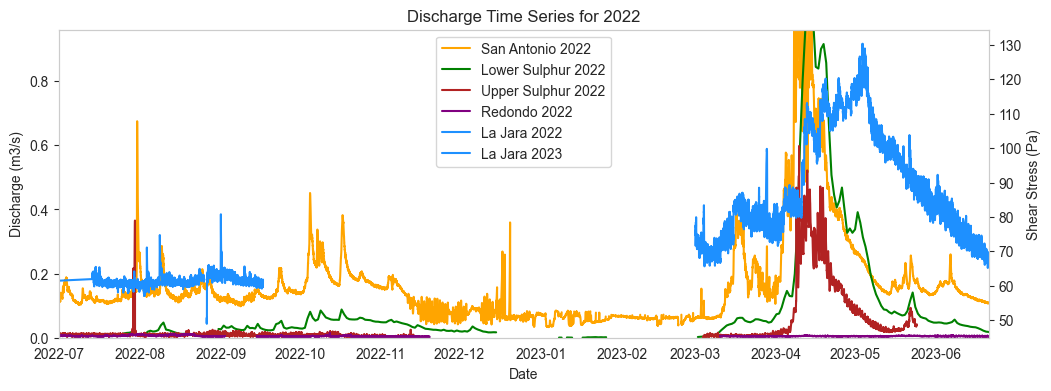

In [88]:
# plot discharge time series for all 4 sites
# 2022
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(san_antonio.index, san_antonio['san_antonio (m3/s)'], label='San Antonio 2022', color='orange')
ax.plot(lower_sulphur.index, lower_sulphur['lower_sulphur (m3/s)'], label='Lower Sulphur 2022', color='green')
ax.plot(upper_sulphur.index, upper_sulphur['upper_sulphur (m3/s)'], label='Upper Sulphur 2022', color='firebrick')
ax.plot(redondo.index, redondo['redondo (m3/s)'], label='Redondo 2022', color='purple')
ax.set_ylabel('Discharge (m3/s)')
ax.grid(False)

ax2 = ax.twinx()
ax2.plot(lajara_2022.index, lajara_2022['la_jara'], label='La Jara 2022', color='dodgerblue')
ax2.plot(lajara_2023.index, lajara_2023['la_jara'], label='La Jara 2023', color= 'dodgerblue')
ax2.set_ylabel('Shear Stress (Pa)')
ax2.grid(False)

# combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='best')

ax.set_ylim(0, 0.96)
ax.set_title('Discharge Time Series for 2022')
ax.set_xlabel('Date')
ax.set_xlim(pd.Timestamp('2022-07-01'), pd.Timestamp('2023-06-21'))
plt.show()

In [89]:
print(san_antonio['san_antonio (m3/s)'].loc['2022-09-01':'2023-02-05'].max())
print(san_antonio['san_antonio (m3/s)'].loc['2022-09-01':'2023-02-05'].idxmax())

0.451093730950464
2022-10-04 23:00:00


## 2021

In [90]:
# merge all onto la_jara 2021 index (inner join to only keep dates available in la_jara_2021)
lajara_2021 = lajara_2021[(lajara_2021.index >= '2021-08-01')]
merged_2021 = lajara_2021.copy()
merged_2021 = merged_2021.join([
    redondo[['redondo (m3/s)']],
    san_antonio[['san_antonio (m3/s)']],
    lower_sulphur[['lower_sulphur (m3/s)']],
    upper_sulphur[['upper_sulphur (m3/s)']],
    jemez[['jemez (ft)']]
], how='left')

print(merged_2021.head())
print(f"Shape: {merged_2021.shape}")

                       la_jara  redondo (m3/s)  san_antonio (m3/s)  \
2021-08-01 00:00:00  64.500604        0.003470            0.114706   
2021-08-01 00:15:00  64.500604        0.003794            0.115739   
2021-08-01 00:30:00  64.500604        0.003763            0.117097   
2021-08-01 00:45:00  64.500604        0.003467            0.120654   
2021-08-01 01:00:00  64.500604        0.003467            0.117900   

                     lower_sulphur (m3/s)  upper_sulphur (m3/s)  jemez (ft)  
2021-08-01 00:00:00              0.014357              0.010209         NaN  
2021-08-01 00:15:00                   NaN              0.010539         NaN  
2021-08-01 00:30:00                   NaN              0.010638         NaN  
2021-08-01 00:45:00                   NaN              0.010510         NaN  
2021-08-01 01:00:00                   NaN              0.010311         NaN  
Shape: (4609, 6)


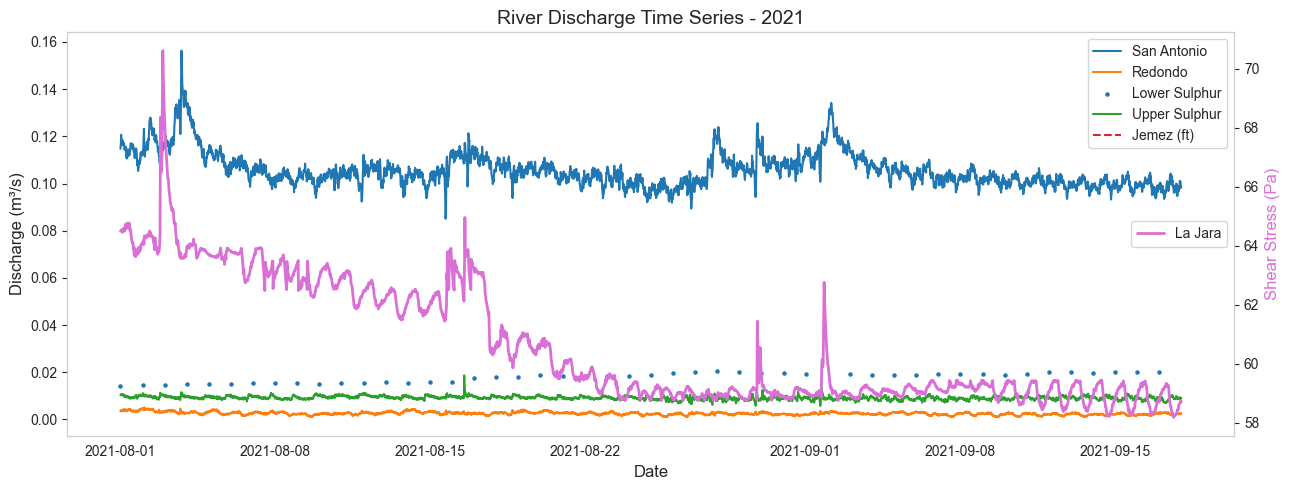

In [93]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.set_style("whitegrid")

ax.plot(merged_2021.index, merged_2021['san_antonio (m3/s)'], label='San Antonio', linewidth=1.5)
ax.plot(merged_2021.index, merged_2021['redondo (m3/s)'], label='Redondo', linewidth=1.5)
ax.scatter(merged_2021.index, merged_2021['lower_sulphur (m3/s)'], label='Lower Sulphur', s=5)
ax.plot(merged_2021.index, merged_2021['upper_sulphur (m3/s)'], label='Upper Sulphur', linewidth=1.5)
ax.plot(merged_2021.index, merged_2021['jemez (ft)'], label='Jemez (ft)', linewidth=1.5, linestyle='--')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Discharge (m³/s)', fontsize=12)
ax.set_title('River Discharge Time Series - 2021', fontsize=14)
ax.legend(loc='best')
ax.grid(False)

ax2 = ax.twinx()
ax2.plot(merged_2021.index, merged_2021['la_jara'], label='La Jara', linewidth=2, color='orchid')
ax2.set_ylabel('Shear Stress (Pa)', fontsize=12, color='orchid')
ax2.legend(loc='center right')
ax2.grid(False)

plt.xticks(rotation=45)
plt.tight_layout()
#plt.ylim(0, 0.1)
plt.show()

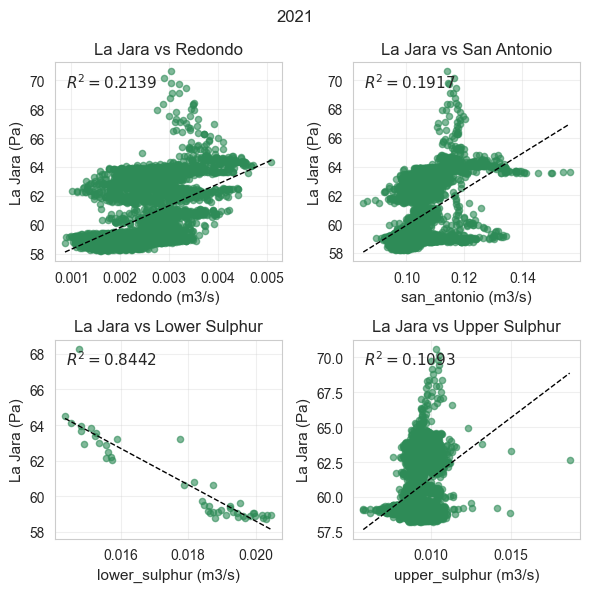

In [94]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
fig.suptitle('2021', fontsize=12)
sns.set_style("whitegrid")

# define the pairs: (x_column, subplot_position, title)
pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    # remove NaN values for the regression
    valid_data = merged_2021[[x_col, 'la_jara']].dropna()
    # scatter plot
    ax.scatter(valid_data[x_col], valid_data['la_jara'], alpha=0.6, s=20, color='seagreen')
    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2
    
    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
    
    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (Pa)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', transform=ax.transAxes, fontsize=11, verticalalignment='top')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2022

In [95]:
lajara_2022 = lajara_2022[(lajara_2022.index >= '2022-08-01')] #& (lajara_2022.index < '2022-08-29')] # only keeping summer 
merged_2022 = lajara_2022.copy()
merged_2022 = merged_2022.join([
    redondo[['redondo (m3/s)']],
    san_antonio[['san_antonio (m3/s)']],
    lower_sulphur[['lower_sulphur (m3/s)']],
    upper_sulphur[['upper_sulphur (m3/s)']],
    jemez[['jemez (ft)']]
], how='left')

print(merged_2022.head())
print(f"Shape: {merged_2022.shape}")

                       la_jara  redondo (m3/s)  san_antonio (m3/s)  \
2022-08-01 00:00:00  60.721384        0.008724            0.250340   
2022-08-01 00:15:00  60.852264        0.008664            0.249357   
2022-08-01 00:30:00  60.090494        0.008425            0.245818   
2022-08-01 00:45:00  60.677277        0.009048            0.245451   
2022-08-01 01:00:00  60.456443        0.008545            0.241461   

                     lower_sulphur (m3/s)  upper_sulphur (m3/s)  jemez (ft)  
2022-08-01 00:00:00              0.007619              0.005346         NaN  
2022-08-01 00:15:00                   NaN              0.005164         NaN  
2022-08-01 00:30:00                   NaN              0.004985         NaN  
2022-08-01 00:45:00                   NaN              0.005385         NaN  
2022-08-01 01:00:00                   NaN              0.005630         NaN  
Shape: (4515, 6)


In [99]:
print(merged_2022['san_antonio (m3/s)'].loc['2022-09-01':'2023-02-05'].max())
print(merged_2022['san_antonio (m3/s)'].loc['2022-09-01':'2023-02-05'].idxmax())

0.1503343887828096
2022-09-15 00:00:00


In [100]:
print(merged_2022.index[:5])
print(san_antonio.index[:5])

DatetimeIndex(['2022-08-01 00:00:00', '2022-08-01 00:15:00',
               '2022-08-01 00:30:00', '2022-08-01 00:45:00',
               '2022-08-01 01:00:00'],
              dtype='datetime64[ns]', freq=None)
DatetimeIndex(['2008-04-16 13:58:00', '2008-04-16 14:08:00',
               '2008-04-16 14:18:00', '2008-04-16 14:28:00',
               '2008-04-16 14:38:00'],
              dtype='datetime64[ns]', name='Timestamp (UTC-07:00)', freq=None)


In [101]:
print(pd.Timestamp("2022-10-04 23:00:00") in merged_2022.index)

False


In [102]:
san_antonio['san_antonio (m3/s)'].count()
merged_2022['san_antonio (m3/s)'].count()

np.int64(4514)

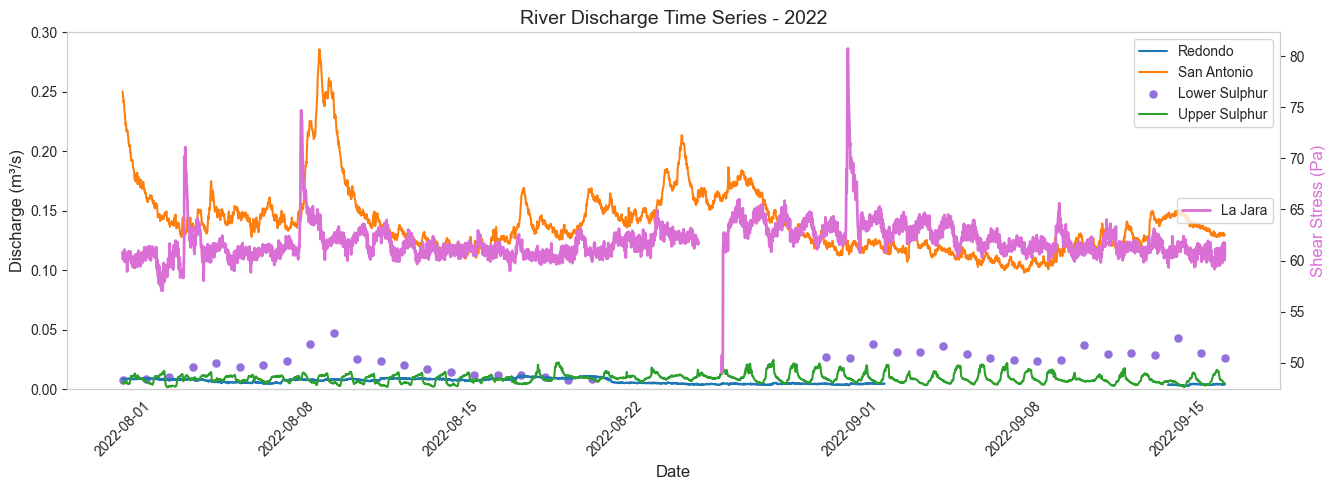

In [97]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.set_style("whitegrid")

ax.plot(merged_2022.index, merged_2022['redondo (m3/s)'], label='Redondo', linewidth=1.5)
ax.plot(merged_2022.index, merged_2022['san_antonio (m3/s)'], label='San Antonio', linewidth=1.5)
ax.scatter(merged_2022.index, merged_2022['lower_sulphur (m3/s)'], label='Lower Sulphur', linewidth=0.1, color='mediumpurple')
ax.plot(merged_2022.index, merged_2022['upper_sulphur (m3/s)'], label='Upper Sulphur', linewidth=1.5)
ax.grid(False)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Discharge (m³/s)', fontsize=12)
ax.set_title('River Discharge Time Series - 2022', fontsize=14)
ax.legend(loc='best')
plt.xticks(rotation=45)
plt.tight_layout()
ax.set_ylim(0, 0.3)


ax2 = ax.twinx()
ax2.plot(merged_2022.index, merged_2022['la_jara'], label='La Jara', linewidth=2, color='orchid')
ax2.set_ylabel('Shear Stress (Pa)', fontsize=12, color='orchid')
ax2.legend(loc='center right')
ax2.grid(False)

#plt.xlim(pd.to_datetime('2022-08-01'), merged_2022.index.max())

plt.show()

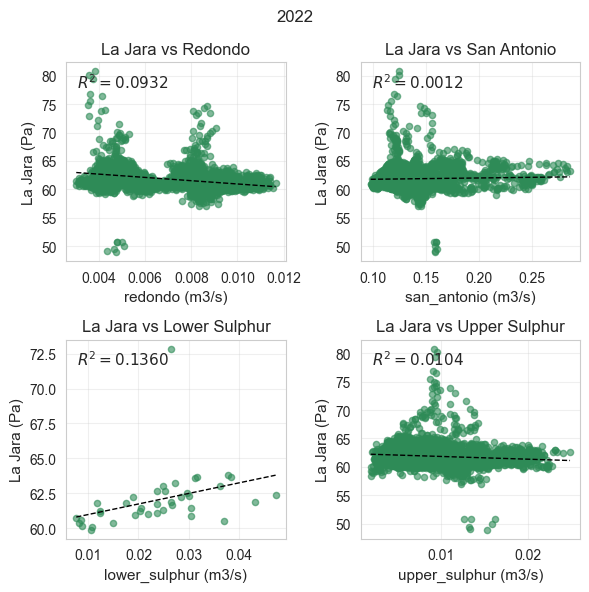

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
fig.suptitle('2022', fontsize=12)
sns.set_style("whitegrid")

# define the pairs: (x_column, subplot_position, title)
pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    # remove NaN values for the regression
    valid_data = merged_2022[[x_col, 'la_jara']].dropna()
    # scatter plot
    ax.scatter(valid_data[x_col], valid_data['la_jara'], alpha=0.6, s=20, color='seagreen')
    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2
    
    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
    
    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (Pa)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', transform=ax.transAxes, fontsize=11, verticalalignment='top')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2023

In [11]:
# merge all onto la_jara 2021 index (inner join to only keep dates available in la_jara_2021)
lajara_2023 = lajara_2023[(lajara_2023.index >= '2023-04-01')] #& (lajara_2023.index < '2023-12-01')] # only keep summer data
merged_2023 = lajara_2023.copy()
merged_2023 = merged_2023.join([
    redondo[['redondo (m3/s)']],
    san_antonio[['san_antonio (m3/s)']],
    lower_sulphur[['lower_sulphur (m3/s)']],
    upper_sulphur[['upper_sulphur (m3/s)']],
    jemez[['jemez (ft)']]
], how='left')

print(merged_2023.head())
print(f"Shape: {merged_2023.shape}")

                       la_jara  redondo (m3/s)  san_antonio (m3/s)  \
2023-04-01 00:00:00  79.798356        0.004080            0.183147   
2023-04-01 00:15:00  79.153686        0.004243                 NaN   
2023-04-01 00:30:00  79.503420        0.004584            0.181196   
2023-04-01 00:45:00  80.609246        0.004275                 NaN   
2023-04-01 01:00:00  79.466979        0.004283            0.173708   

                     lower_sulphur (m3/s)  upper_sulphur (m3/s)  jemez (ft)  
2023-04-01 00:00:00              0.073167              0.008996        4.25  
2023-04-01 00:15:00                   NaN                   NaN        4.25  
2023-04-01 00:30:00                   NaN              0.008445        4.25  
2023-04-01 00:45:00                   NaN                   NaN        4.25  
2023-04-01 01:00:00                   NaN              0.008564        4.25  
Shape: (16325, 6)


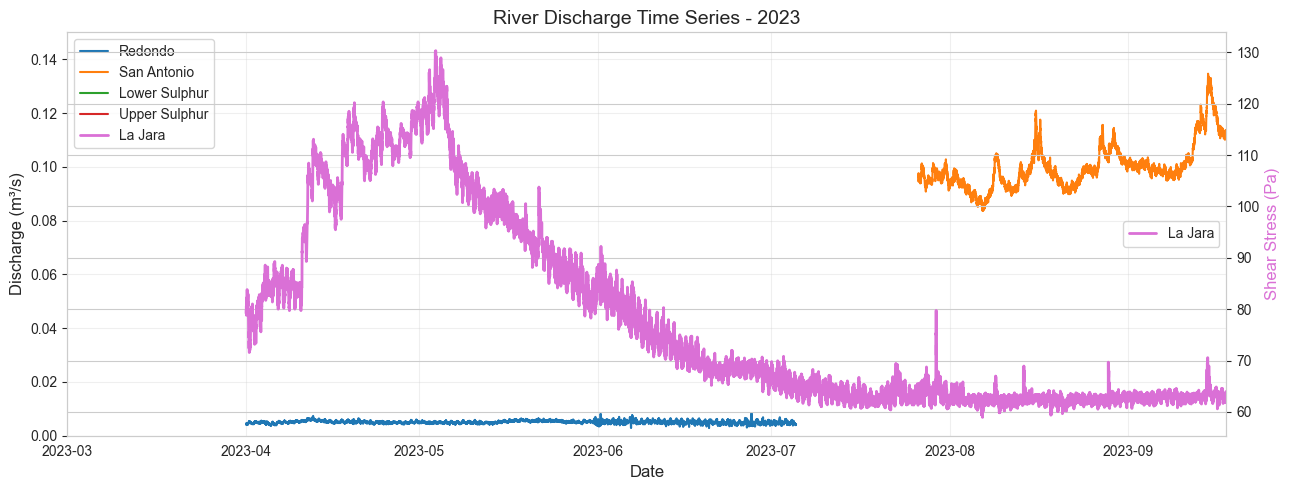

In [12]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.set_style("whitegrid")


ax.plot(merged_2023.index, merged_2023['redondo (m3/s)'], label='Redondo', linewidth=1.5)
ax.plot(merged_2023.index, merged_2023['san_antonio (m3/s)'], label='San Antonio', linewidth=1.5)
ax.plot(merged_2023.index, merged_2023['lower_sulphur (m3/s)'], label='Lower Sulphur', linewidth=1.5)
ax.plot(merged_2023.index, merged_2023['upper_sulphur (m3/s)'], label='Upper Sulphur', linewidth=1.5)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Discharge (m³/s)', fontsize=12)
ax.set_title('River Discharge Time Series - 2023', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 0.15)

# twin axis for Jemez gauge height
ax2 = ax.twinx()
ax2.plot(merged_2023.index, merged_2023['la_jara'], label='La Jara', linewidth=2, color='orchid')
ax2.set_ylabel('Shear Stress (Pa)', fontsize=12, color='orchid')
ax2.legend(loc='center right')

# combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.xlim(pd.to_datetime('2023-03-01'), merged_2023.index.max())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

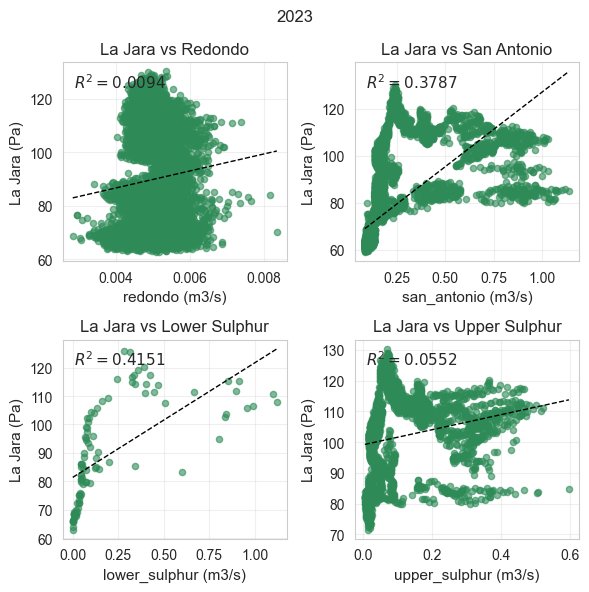

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
fig.suptitle('2023', fontsize=12)
sns.set_style("whitegrid")

# define the pairs: (x_column, subplot_position, title)
pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    # remove NaN values for the regression
    valid_data = merged_2023[[x_col, 'la_jara']].dropna()
    # scatter plot
    ax.scatter(valid_data[x_col], valid_data['la_jara'], alpha=0.6, s=20, color='seagreen')
    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2
    
    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
    
    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (Pa)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', transform=ax.transAxes, fontsize=11, verticalalignment='top')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

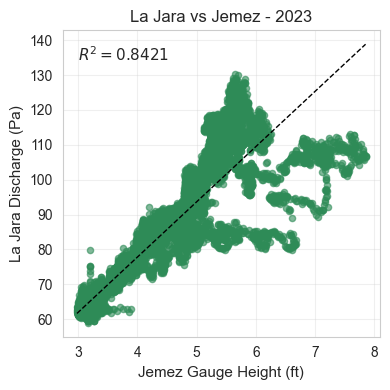

In [14]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.set_style("whitegrid")

# remove NaN values for the regression
valid_data = merged_2023[['jemez (ft)', 'la_jara']].dropna()

# scatter plot
ax.scatter(valid_data['jemez (ft)'], valid_data['la_jara'], alpha=0.6, s=20, color='seagreen')

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(valid_data['jemez (ft)'], valid_data['la_jara'])
r2 = r_value**2

# plot regression line
x_line = np.array([valid_data['jemez (ft)'].min(), valid_data['jemez (ft)'].max()])
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)

# Labels and title with R² value
ax.set_xlabel('Jemez Gauge Height (ft)', fontsize=11)
ax.set_ylabel('La Jara Discharge (Pa)', fontsize=11)
ax.set_title('La Jara vs Jemez - 2023', fontsize=12)
ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', transform=ax.transAxes, fontsize=11, verticalalignment='top')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## All years

In [15]:
# combine all years
merged_all = pd.concat([merged_2021, merged_2022, merged_2023])

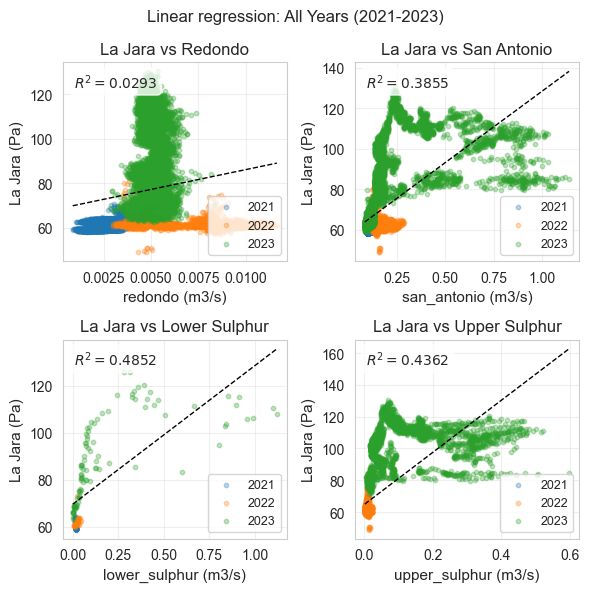

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Linear regression: All Years (2021-2023)', fontsize=12)

pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

colors = {'2021': '#1f77b4', '2022': '#ff7f0e', '2023': '#2ca02c'}  # blue, orange, green

for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    
    # scatter plot by year with different colors
    for year, color in colors.items():
        year_data = valid_data[valid_data.index.year == int(year)]
        ax.scatter(year_data[x_col], year_data['la_jara'], alpha=0.3, s=10, color=color, label=year)
    
    # linear regression
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2
    
    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
    
    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (Pa)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [17]:
pairs = [
    ('redondo (m3/s)', 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', 'La Jara vs Upper Sulphur')
]

print("Linear Regression Metrics: All Years (2021-2023)\n")
print("-" * 80)

for x_col, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()

    if len(valid_data) < 2:
        print(f"{title}: not enough data\n")
        continue

    x = valid_data[x_col].values
    y = valid_data['la_jara'].values

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2 = r_value**2

    print(f"{title}:")
    print(f"  Equation: y = {slope:.6f} * x + {intercept:.6f}")
    print(f"  R² = {r2:.4f}")
    print(f"  p-value = {p_value:.4e}")
    print(f"  Std Err (slope) = {std_err:.6f}")
    print(f"  n = {len(valid_data)}")
    print()

print("-" * 80)

Linear Regression Metrics: All Years (2021-2023)

--------------------------------------------------------------------------------
La Jara vs Redondo:
  Equation: y = 1780.836517 * x + 68.259888
  R² = 0.0293
  p-value = 5.7486e-112
  Std Err (slope) = 78.610685
  n = 17026

La Jara vs San Antonio:
  Equation: y = 70.270108 * x + 57.972921
  R² = 0.3855
  p-value = 0.0000e+00
  Std Err (slope) = 0.631421
  n = 19744

La Jara vs Lower Sulphur:
  Equation: y = 58.983941 * x + 69.463959
  R² = 0.4852
  p-value = 2.4980e-28
  Std Err (slope) = 4.479408
  n = 186

La Jara vs Upper Sulphur:
  Equation: y = 163.861977 * x + 64.711237
  R² = 0.4362
  p-value = 0.0000e+00
  Std Err (slope) = 1.729877
  n = 11600

--------------------------------------------------------------------------------


### Different curve types

In [18]:
from scipy.optimize import curve_fit

# define exponential function
def exponential(x, a, b):
    return a * np.exp(b * x)

def logarithmic(x, a, b):
    return a * np.log(x) + b

def power_law(x, a, b):
    return a * x**b

Exponential

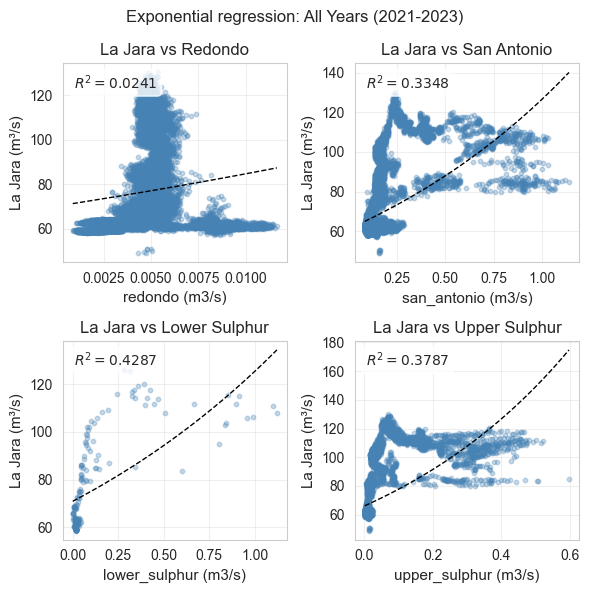

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Exponential regression: All Years (2021-2023)', fontsize=12)

pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    
    # scatter plot
    ax.scatter(x, y, alpha=0.3, s=10, color='steelblue')
    # exponential regression
    try:
        popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)
        
        # Calculate R²
        y_pred = exponential(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        
        # plot regression line
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = exponential(x_line, *popt)
        ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
        
        # Labels and title with R² value
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (m³/s)', fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    except:
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (Pa)', fontsize=11)
        ax.set_title(title + ' (fit failed)', fontsize=12)
    
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# print the equations for each subplot
equations = []
for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    try:
        popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)
        equation = f"y = {popt[0]:.4f} * e^({popt[1]:.4f} * x)"
        equations.append(equation)
        y_pred = exponential(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        print(f"{title}: {equation}, R² = {r2:.4f}")
    except:
        equations.append("Failed to fit")
        print(f"{title}: Failed to fit")

La Jara vs Redondo: y = 70.1066 * e^(18.8641 * x), R² = 0.0241
La Jara vs San Antonio: y = 61.1703 * e^(0.7268 * x), R² = 0.3348
La Jara vs Lower Sulphur: y = 70.9263 * e^(0.5688 * x), R² = 0.4287
La Jara vs Upper Sulphur: y = 66.0538 * e^(1.6288 * x), R² = 0.3787


Logarithmic

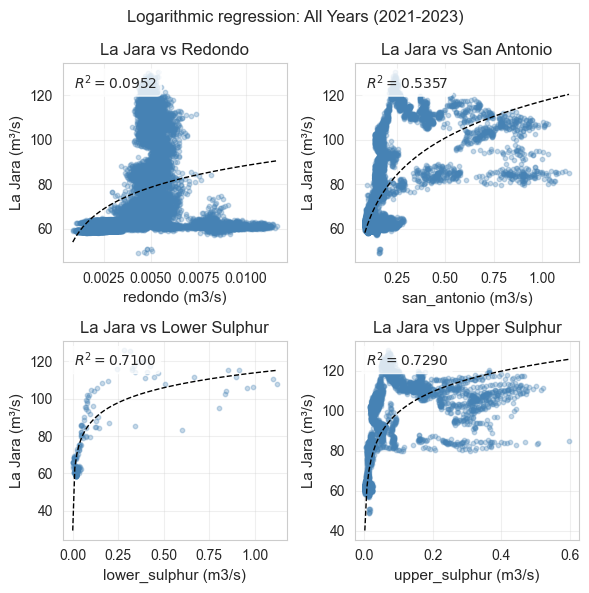

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Logarithmic regression: All Years (2021-2023)', fontsize=12)

pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    
    # scatter plot
    ax.scatter(x, y, alpha=0.3, s=10, color='steelblue')
    # logarithmic regression
    try:
        popt, _ = curve_fit(logarithmic, x, y, p0=[0.01, 0.1], maxfev=5000)
        
        # Calculate R²
        y_pred = logarithmic(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        
        # plot regression line
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = logarithmic(x_line, *popt)
        ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
        
        # Labels and title with R² value
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (m³/s)', fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    except:
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (Pa)', fontsize=11)
        ax.set_title(title + ' (fit failed)', fontsize=12)
    
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# print the equations for each subplot
equations = []
for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    try:
        popt, _ = curve_fit(logarithmic, x, y, p0=[0.01, 0.1], maxfev=5000)
        equation = f"y = {popt[0]:.4f} * ln({popt[1]:.4f} * x)"
        equations.append(equation)
        y_pred = logarithmic(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        print(f"{title}: {equation}, R² = {r2:.4f}")
    except:
        equations.append("Failed to fit")
        print(f"{title}: Failed to fit")

La Jara vs Redondo: y = 14.0955 * ln(153.2856 * x), R² = 0.0952
La Jara vs San Antonio: y = 23.8211 * ln(117.3479 * x), R² = 0.5357
La Jara vs Lower Sulphur: y = 11.5136 * ln(113.7683 * x), R² = 0.7100
La Jara vs Upper Sulphur: y = 14.7663 * ln(133.2385 * x), R² = 0.7290


Power Law

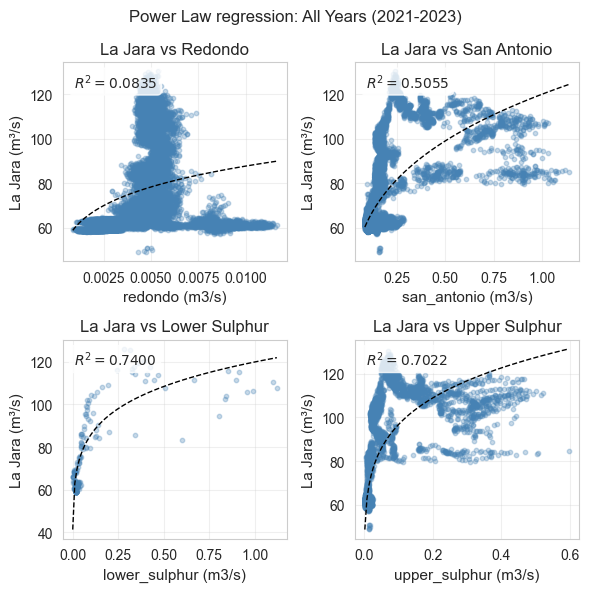

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Power Law regression: All Years (2021-2023)', fontsize=12)

pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    
    # scatter plot
    ax.scatter(x, y, alpha=0.3, s=10, color='steelblue')
    # power law regression
    try:
        popt, _ = curve_fit(power_law, x, y, p0=[0.01, 0.1], maxfev=5000)
        
        # Calculate R²
        y_pred = power_law(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        
        # plot regression line
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = power_law(x_line, *popt)
        ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
        
        # Labels and title with R² value
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (m³/s)', fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    except:
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (Pa)', fontsize=11)
        ax.set_title(title + ' (fit failed)', fontsize=12)
    
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# print the equations for each subplot
equations = []
for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    try:
        popt, _ = curve_fit(power_law, x, y, p0=[0.01, 0.1], maxfev=5000)
        equation = f"y = {popt[0]:.4f} * x^{popt[1]:.4f}"
        equations.append(equation)
        y_pred = power_law(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        print(f"{title}: {equation}, R² = {r2:.4f}")
    except:
        equations.append("Failed to fit")
        print(f"{title}: Failed to fit")

La Jara vs Redondo: y = 186.3124 * x^0.1637, R² = 0.0835
La Jara vs San Antonio: y = 120.0026 * x^0.2773, R² = 0.5055
La Jara vs Lower Sulphur: y = 119.8530 * x^0.1455, R² = 0.7400
La Jara vs Upper Sulphur: y = 143.5442 * x^0.1714, R² = 0.7022


## Only fitting lower range of data

In [80]:
# finding the max value of the low-flow period in 2022
redondo_low_flow_2022 = merged_all['redondo (m3/s)'][(merged_all.index >= '2022-07-10') & (merged_all.index <= '2023-02-19')]
san_antonio_low_flow_2022 = merged_all['san_antonio (m3/s)'][(merged_all.index >= '2022-07-01') & (merged_all.index <= '2023-02-05')]
lower_sulphur_low_flow_2022 = merged_all['lower_sulphur (m3/s)'][(merged_all.index >= '2022-07-01') & (merged_all.index <= '2023-02-05')]
upper_sulphur_low_flow_2022 = merged_all['upper_sulphur (m3/s)'][(merged_all.index >= '2022-07-01') & (merged_all.index <= '2023-02-05')]
jemez_low_flow_2022 = merged_all['jemez (ft)'][(merged_all.index >= '2023-07-01') & (merged_all.index <= '2023-09-05')]

print(f"Max Redondo low flow 2022: {redondo_low_flow_2022.max():.4f} m³/s")
print(f"Max San Antonio low flow 2022: {san_antonio_low_flow_2022.max():.4f} m³/s")
print(f"Max Lower Sulphur low flow 2022: {lower_sulphur_low_flow_2022.max():.4f} m³/s")
print(f"Max Upper Sulphur low flow 2022: {upper_sulphur_low_flow_2022.max():.4f} m³/s")
print(f"Max Jemez low flow 2022: {jemez_low_flow_2022.max():.4f} ft")

Max Redondo low flow 2022: 0.0117 m³/s
Max San Antonio low flow 2022: 0.2859 m³/s
Max Lower Sulphur low flow 2022: 0.0473 m³/s
Max Upper Sulphur low flow 2022: 0.0249 m³/s
Max Jemez low flow 2022: 3.9000 ft


In [81]:
san = merged_all['san_antonio (m3/s)'].loc['2022-09-01':'2023-02-05']
print(san.max())
print(san.idxmax())

0.1503343887828096
2022-09-15 00:00:00


In [26]:
#merged_all = merged_all[merged_all['la_jara'] <= 0.02] # only keep baseflow la jara

merged_redondo = merged_all[['redondo (m3/s)', 'la_jara']].dropna()
merged_san_antonio = merged_all[['san_antonio (m3/s)', 'la_jara']].dropna()
merged_lower_sulphur = merged_all[['lower_sulphur (m3/s)', 'la_jara']].dropna()
merged_upper_sulphur = merged_all[['upper_sulphur (m3/s)', 'la_jara']].dropna()
merged_jemez = merged_all[['jemez (ft)', 'la_jara']].dropna()

# only keep rows where discharge is less than or equal to the max low flow 
merged_redondo = merged_redondo[merged_redondo['redondo (m3/s)'] <= redondo_low_flow_2022.max()*1] 
merged_san_antonio = merged_san_antonio[merged_san_antonio['san_antonio (m3/s)'] <= san_antonio_low_flow_2022.max()*1] 
merged_lower_sulphur = merged_lower_sulphur[merged_lower_sulphur['lower_sulphur (m3/s)'] <= lower_sulphur_low_flow_2022.max()*1]
merged_upper_sulphur = merged_upper_sulphur[merged_upper_sulphur['upper_sulphur (m3/s)'] <= upper_sulphur_low_flow_2022.max()*1]
merged_jemez = merged_jemez[merged_jemez['jemez (ft)'] <= jemez_low_flow_2022.max()*1]

### Linear Low Flows

Redondo, San Antonio, Sulphur

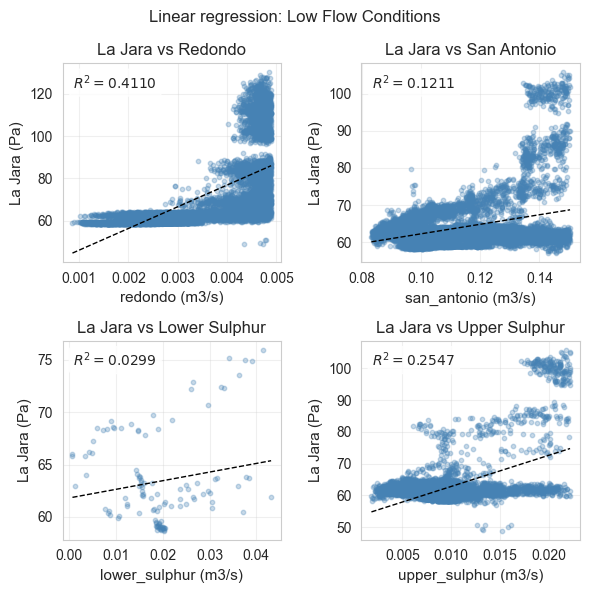

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Linear regression: Low Flow Conditions', fontsize=12)

pairs = [
    (merged_redondo, 'redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    (merged_san_antonio, 'san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    (merged_lower_sulphur, 'lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    (merged_upper_sulphur, 'upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, 'la_jara']].dropna()
    # scatter plot
    ax.scatter(valid_data[x_col], valid_data['la_jara'], alpha=0.3, s=10, color='steelblue')
    
    # linear regression
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2
    
    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
    
    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (Pa)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# print linear equations and metrics for low flow conditions
pairs = [
    (merged_redondo, 'redondo (m3/s)', 'La Jara vs Redondo'),
    (merged_san_antonio, 'san_antonio (m3/s)', 'La Jara vs San Antonio'),
    (merged_lower_sulphur, 'lower_sulphur (m3/s)', 'La Jara vs Lower Sulphur'),
    (merged_upper_sulphur, 'upper_sulphur (m3/s)', 'La Jara vs Upper Sulphur')
]
print("Linear Regression: Low Flow Conditions\n")
print("-" * 70)

for df, x_col, title in pairs:
    valid_data = df[[x_col, 'la_jara']].dropna()
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    
    try:
        # perform linear regression
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        r2 = r_value**2
        
        equation = f"y = {slope:.6f} * x + {intercept:.6f}"
        print(f"{title}:")
        print(f"  Equation: {equation}")
        print(f"  R² = {r2:.4f}")
        print(f"  n = {len(valid_data)}")
        print()
    except:
        print(f"{title}: Failed to fit\n")

print("-" * 70)

Linear Regression: Low Flow Conditions

----------------------------------------------------------------------
La Jara vs Redondo:
  Equation: y = 10278.138335 * x + 35.723932
  R² = 0.4110
  n = 8811

La Jara vs San Antonio:
  Equation: y = 128.672860 * x + 49.371932
  R² = 0.1211
  n = 15936

La Jara vs Lower Sulphur:
  Equation: y = 82.260043 * x + 61.818797
  R² = 0.0299
  n = 115

La Jara vs Upper Sulphur:
  Equation: y = 979.404888 * x + 53.037040
  R² = 0.2547
  n = 9396

----------------------------------------------------------------------


Jemez 

  Equation: y = 15.653114 * x + 13.972895
  R² = 0.6980


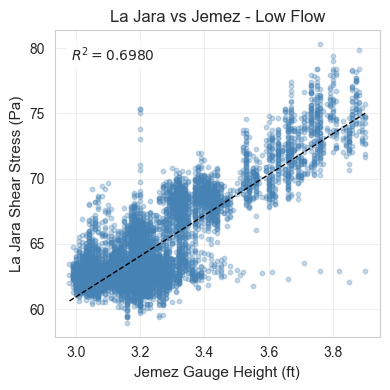

In [29]:
# jemez river height vs la jara discharge during low flow
fig, ax = plt.subplots(figsize=(4, 4))
sns.set_style("whitegrid")
valid_data = merged_jemez[['jemez (ft)', 'la_jara']].dropna()
ax.scatter(valid_data['jemez (ft)'], valid_data['la_jara'], alpha=0.3, s=10, color='steelblue')
slope, intercept, r_value, p_value, std_err = linregress(valid_data['jemez (ft)'], valid_data['la_jara'])
r2 = r_value**2
x_line = np.array([valid_data['jemez (ft)'].min(), valid_data['jemez (ft)'].max()])
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Jemez Gauge Height (ft)', fontsize=11)
ax.set_ylabel('La Jara Shear Stress (Pa)', fontsize=11)
ax.set_title('La Jara vs Jemez - Low Flow', fontsize=12)
ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.grid(True, alpha=0.3)
# print the equation
equation = f"y = {slope:.6f} * x + {intercept:.6f}"
print(f"  Equation: {equation}")
print(f"  R² = {r2:.4f}")
plt.tight_layout()
plt.show()

### Exponential Low Flows

Redondo, San Antonio, Sulphur

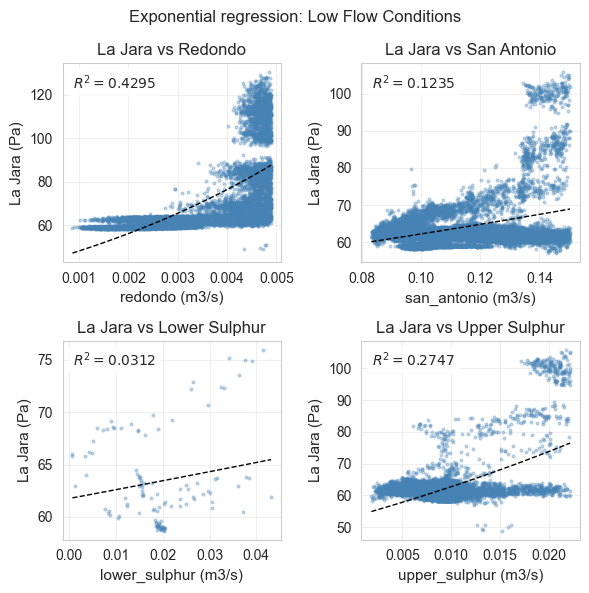

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Exponential regression: Low Flow Conditions', fontsize=12)

pairs = [
    (merged_redondo, 'redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    (merged_san_antonio, 'san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    (merged_lower_sulphur, 'lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    (merged_upper_sulphur, 'upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]
for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, 'la_jara']].dropna()
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    
    # scatter plot by year with different colors
    for year, color in colors.items():
        year_data = valid_data[valid_data.index.year == int(year)]
        ax.scatter(year_data[x_col], year_data['la_jara'], alpha=0.3, s=4, color='steelblue', label=year)
    
    # exponential regression
    try:
        popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)
        
        # Calculate R²
        y_pred = exponential(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
    
        # plot regression line
        x_line = np.linspace(valid_data[x_col].min(), valid_data[x_col].max(), 100)
        y_line = exponential(x_line, *popt)
        ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
        # Labels and title with R² value
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (Pa)', fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.grid(True, alpha=0.3)
    except:
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (Pa)', fontsize=11)
        ax.set_title(title + ' (fit failed)', fontsize=12)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Equation Metrics

In [31]:
# print exponential equations and metrics for low flow conditions
pairs = [
    (merged_redondo, 'redondo (m3/s)', 'La Jara vs Redondo'),
    (merged_san_antonio, 'san_antonio (m3/s)', 'La Jara vs San Antonio'),
    (merged_lower_sulphur, 'lower_sulphur (m3/s)', 'La Jara vs Lower Sulphur'),
    (merged_upper_sulphur, 'upper_sulphur (m3/s)', 'La Jara vs Upper Sulphur')
]
print("Exponential Regression: Low Flow Conditions\n")
print("-" * 70)

for df, x_col, title in pairs:
    valid_data = df[[x_col, 'la_jara']].dropna()
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    
    try:
        popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)
        
        # calculate R²
        y_pred = exponential(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        
        equation = f"y = {popt[0]:.6f} * e^({popt[1]:.6f} * x)"
        print(f"{title}:")
        print(f"  Equation: {equation}")
        print(f"  R² = {r2:.4f}")
        print(f"  n = {len(valid_data)}")
        print()
    except:
        print(f"{title}: Failed to fit\n")

print("-" * 70)

Exponential Regression: Low Flow Conditions

----------------------------------------------------------------------
La Jara vs Redondo:
  Equation: y = 41.232822 * e^(153.885600 * x)
  R² = 0.4295
  n = 8811

La Jara vs San Antonio:
  Equation: y = 50.745780 * e^(2.037079 * x)
  R² = 0.1235
  n = 15936

La Jara vs Lower Sulphur:
  Equation: y = 61.768451 * e^(1.352034 * x)
  R² = 0.0312
  n = 115

La Jara vs Upper Sulphur:
  Equation: y = 53.353205 * e^(16.227751 * x)
  R² = 0.2747
  n = 9396

----------------------------------------------------------------------


Jemez

  Equation: y = 30.053917 * e^(0.236314 * x)
  R² = 0.7047


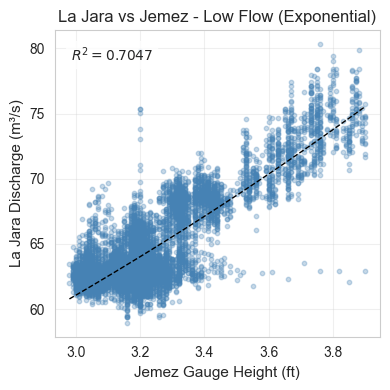

In [32]:
# jemez river height vs la jara discharge during low flow
fig, ax = plt.subplots(figsize=(4, 4))
sns.set_style("whitegrid")
valid_data = merged_jemez[['jemez (ft)', 'la_jara']].dropna()

x = valid_data['jemez (ft)'].values
y = valid_data['la_jara'].values

# scatter plot
ax.scatter(x, y, alpha=0.3, s=10, color='steelblue')

# exponential regression
try:
    popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)
    
    # Calculate R²
    y_pred = exponential(x, *popt)
    residuals = y - y_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - (ss_res / ss_tot)
    
    # plot exponential curve
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = exponential(x_line, *popt)
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
    
    ax.set_xlabel('Jemez Gauge Height (ft)', fontsize=11)
    ax.set_ylabel('La Jara Discharge (m³/s)', fontsize=11)
    ax.set_title('La Jara vs Jemez - Low Flow (Exponential)', fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
except:
    ax.set_xlabel('Jemez Gauge Height (ft)', fontsize=11)
    ax.set_ylabel('La Jara Shear Stress (Pa)', fontsize=11)
    ax.set_title('La Jara vs Jemez - Low Flow (fit failed)', fontsize=12)

# print the equation
equation = f"y = {popt[0]:.6f} * e^({popt[1]:.6f} * x)" if 'popt' in locals() else "Fit failed"
print(f"  Equation: {equation}")
print(f"  R² = {r2:.4f}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Separate by year

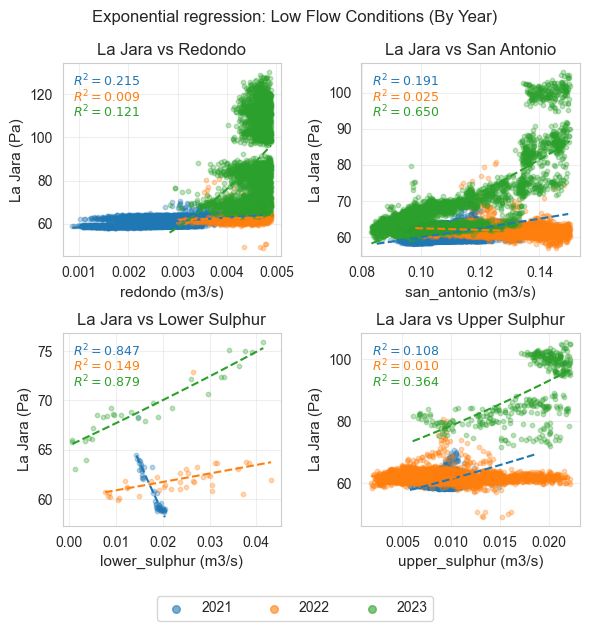

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Exponential regression: Low Flow Conditions (By Year)', fontsize=12)

pairs = [
    (merged_redondo, 'redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    (merged_san_antonio, 'san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    (merged_lower_sulphur, 'lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    (merged_upper_sulphur, 'upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

colors = {'2021': '#1f77b4', '2022': '#ff7f0e', '2023': '#2ca02c'}  # blue, orange, green

for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, 'la_jara']].dropna()
    y_position = 0.95
    
    # fit exponential regression for each year separately
    for year, color in colors.items():
        year_data = valid_data[valid_data.index.year == int(year)]
        
        if len(year_data) > 0:
            x = year_data[x_col].values
            y = year_data['la_jara'].values
            
            # scatter plot
            ax.scatter(x, y, alpha=0.3, s=10, color=color, label=year)
            
            # exponential regression for this year
            try:
                popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)
                
                # Calculate R²
                y_pred = exponential(x, *popt)
                residuals = y - y_pred
                ss_res = np.sum(residuals**2)
                ss_tot = np.sum((y - np.mean(y))**2)
                r2 = 1 - (ss_res / ss_tot)
                
                # plot regression line
                x_line = np.linspace(x.min(), x.max(), 100)
                y_line = exponential(x_line, *popt)
                ax.plot(x_line, y_line, color=color, linestyle='--', linewidth=1.5)
                
                # Add R² text with matching color
                ax.text(0.05, y_position, f'$R^2 = {r2:.3f}$', 
                       transform=ax.transAxes, fontsize=9, verticalalignment='top',
                       color=color, weight='bold')
                y_position -= 0.08
                
            except:
                pass
    
    # Labels and title
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (Pa)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)

# Create a single legend at the bottom
handles = [plt.scatter([], [], color=colors[year], s=30, alpha=0.6) for year in ['2021', '2022', '2023']]
fig.legend(handles, ['2021', '2022', '2023'], loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

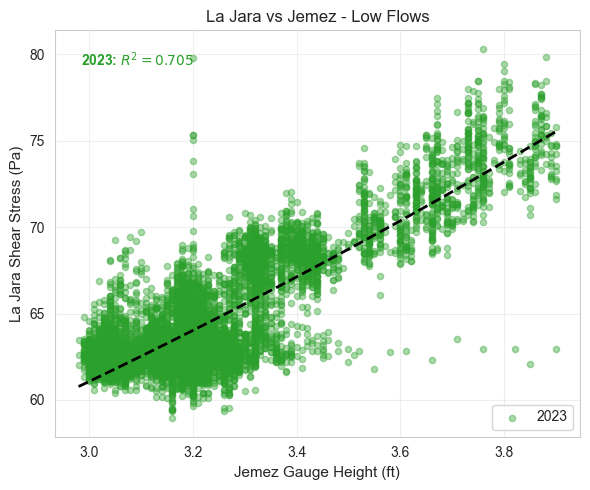

In [34]:
# jemez river height vs la jara discharge during low flow - by year
fig, ax = plt.subplots(figsize=(6, 5))
sns.set_style("whitegrid")
valid_data = merged_jemez[['jemez (ft)', 'la_jara']].dropna()

colors = {'2021': '#1f77b4', '2022': '#ff7f0e', '2023': '#2ca02c'}
y_position = 0.95

# fit exponential regression for each year separately
for year, color in colors.items():
    year_data = valid_data[valid_data.index.year == int(year)]
    
    if len(year_data) > 0:
        x = year_data['jemez (ft)'].values
        y = year_data['la_jara'].values
        
        # scatter plot
        ax.scatter(x, y, alpha=0.4, s=20, color=color, label=year)
        
        # exponential regression for this year
        try:
            popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)
            
            # Calculate R²
            y_pred = exponential(x, *popt)
            residuals = y - y_pred
            ss_res = np.sum(residuals**2)
            ss_tot = np.sum((y - np.mean(y))**2)
            r2 = 1 - (ss_res / ss_tot)
            
            # plot regression line
            x_line = np.linspace(x.min(), x.max(), 100)
            y_line = exponential(x_line, *popt)
            ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=2)
            
            # Add R² text with matching color
            ax.text(0.05, y_position, f'{year}: $R^2 = {r2:.3f}$', 
                   transform=ax.transAxes, fontsize=10, verticalalignment='top',
                   color=color, weight='bold')
            y_position -= 0.1
            
        except:
            pass

ax.set_xlabel('Jemez Gauge Height (ft)', fontsize=11)
ax.set_ylabel('La Jara Shear Stress (Pa)', fontsize=11)
ax.set_title('La Jara vs Jemez - Low Flows', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# Print exponential equations and metrics for jemez vs la jara by year
valid_data = merged_jemez[['jemez (ft)', 'la_jara']].dropna()

print("Exponential Regression: Jemez vs La Jara (Low Flow)\n")
print("-" * 70)

for year, color in colors.items():
    year_data = valid_data[valid_data.index.year == int(year)]
    
    if len(year_data) > 0:
        x = year_data['jemez (ft)'].values
        y = year_data['la_jara'].values
        
        try:
            popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)
            
            # Calculate R²
            y_pred = exponential(x, *popt)
            residuals = y - y_pred
            ss_res = np.sum(residuals**2)
            ss_tot = np.sum((y - np.mean(y))**2)
            r2 = 1 - (ss_res / ss_tot)
            
            equation = f"y = {popt[0]:.6f} * e^({popt[1]:.6f} * x)"
            print(f"{year}:")
            print(f"  Equation: {equation}")
            print(f"  R² = {r2:.4f}")
            print(f"  n = {len(year_data)}")
            print()
        except:
            print(f"{year}: Failed to fit\n")

print("-" * 70)

Exponential Regression: Jemez vs La Jara (Low Flow)

----------------------------------------------------------------------
2023:
  Equation: y = 30.053917 * e^(0.236314 * x)
  R² = 0.7047
  n = 9637

----------------------------------------------------------------------


### What if we ignore storm events (high flows?)

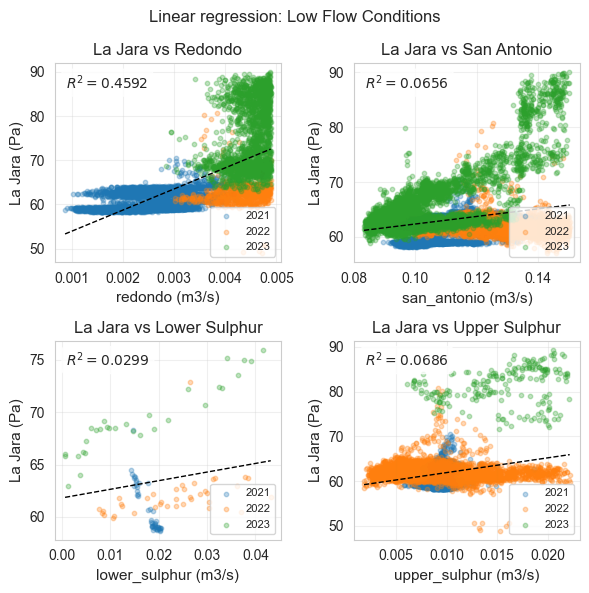

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Linear regression: Low Flow Conditions', fontsize=12)

pairs = [
    (merged_redondo, 'redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    (merged_san_antonio, 'san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    (merged_lower_sulphur, 'lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    (merged_upper_sulphur, 'upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

colors = {'2021': '#1f77b4', '2022': '#ff7f0e', '2023': '#2ca02c'}

for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, 'la_jara']].dropna()
    valid_data = valid_data[(valid_data['la_jara'] <= 90)]

    # scatter plot by year
    for year, color in colors.items():
        year_data = valid_data[valid_data.index.year == int(year)]
        if len(year_data) > 0:
            ax.scatter(year_data[x_col], year_data['la_jara'], alpha=0.3, s=10, color=color, label=year)

    # linear regression on all filtered data
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2

    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)

    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (Pa)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

In [37]:
pairs = [
    ('redondo (m3/s)', 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', 'La Jara vs Upper Sulphur')
]

print("Linear Regression Metrics: Low Flows (2021-2022)\n")
print("-" * 80)

for x_col, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    valid_data = valid_data[valid_data['la_jara'] <= 67]
    valid_data = valid_data[valid_data['la_jara'] >= 58]

    if len(valid_data) < 2:
        print(f"{title}: not enough data\n")
        continue

    x = valid_data[x_col].values
    y = valid_data['la_jara'].values

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2 = r_value**2

    print(f"{title}:")
    print(f"  Equation: y = {slope:.6f} * x + {intercept:.6f}")
    print(f"  R² = {r2:.4f}")
    print(f"  p-value = {p_value:.4e}")
    print(f"  Std Err (slope) = {std_err:.6f}")
    print(f"  n = {len(valid_data)}")
    print()

print("-" * 80)

Linear Regression Metrics: Low Flows (2021-2022)

--------------------------------------------------------------------------------
La Jara vs Redondo:
  Equation: y = 174.151799 * x + 60.508457
  R² = 0.0454
  p-value = 1.6260e-84
  Std Err (slope) = 8.836197
  n = 8172

La Jara vs San Antonio:
  Equation: y = -2.387895 * x + 62.187299
  R² = 0.0010
  p-value = 1.1419e-04
  Std Err (slope) = 0.618739
  n = 15184

La Jara vs Lower Sulphur:
  Equation: y = -35.852576 * x + 62.131282
  R² = 0.0239
  p-value = 1.4346e-01
  Std Err (slope) = 24.289749
  n = 91

La Jara vs Upper Sulphur:
  Equation: y = -3.491531 * x + 61.191344
  R² = 0.0000
  p-value = 6.1433e-01
  Std Err (slope) = 6.928778
  n = 8923

--------------------------------------------------------------------------------


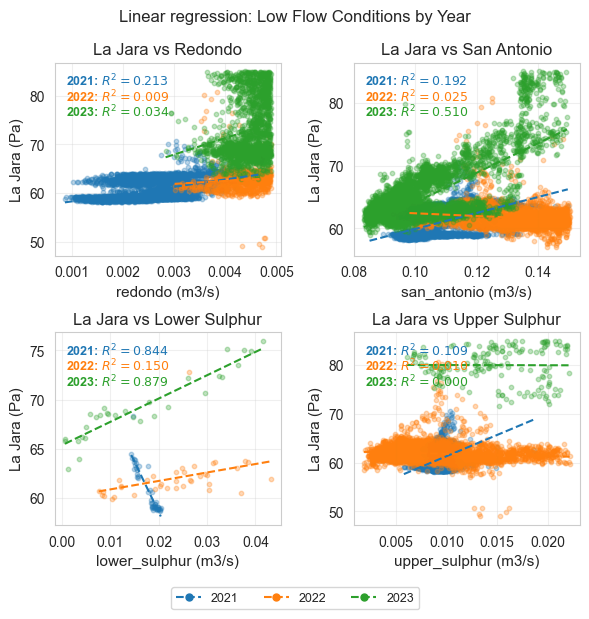

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Linear regression: Low Flow Conditions by Year', fontsize=12)

pairs = [
    (merged_redondo, 'redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    (merged_san_antonio, 'san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    (merged_lower_sulphur, 'lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    (merged_upper_sulphur, 'upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

colors = {'2021': '#1f77b4', '2022': '#ff7f0e', '2023': '#2ca02c'}

for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, 'la_jara']].dropna()
    valid_data = valid_data[valid_data['la_jara'] <= 85]

    y_position = 0.95

    for year, color in colors.items():
        year_data = valid_data[valid_data.index.year == int(year)]

        if len(year_data) < 2:
            continue

        ax.scatter(year_data[x_col], year_data['la_jara'], alpha=0.3, s=10, color=color, label=year)

        slope, intercept, r_value, p_value, std_err = linregress(year_data[x_col], year_data['la_jara'])
        r2 = r_value**2

        x_line = np.array([year_data[x_col].min(), year_data[x_col].max()])
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, color=color, linestyle='--', linewidth=1.5)

        ax.text(
            0.05, y_position, f'{year}: $R^2 = {r2:.3f}$',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            color=color, weight='bold'
        )
        y_position -= 0.08

    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (Pa)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)

handles = [plt.Line2D([0], [0], color=color, marker='o', linestyle='--', linewidth=1.5, markersize=5, label=year) for year, color in colors.items()]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

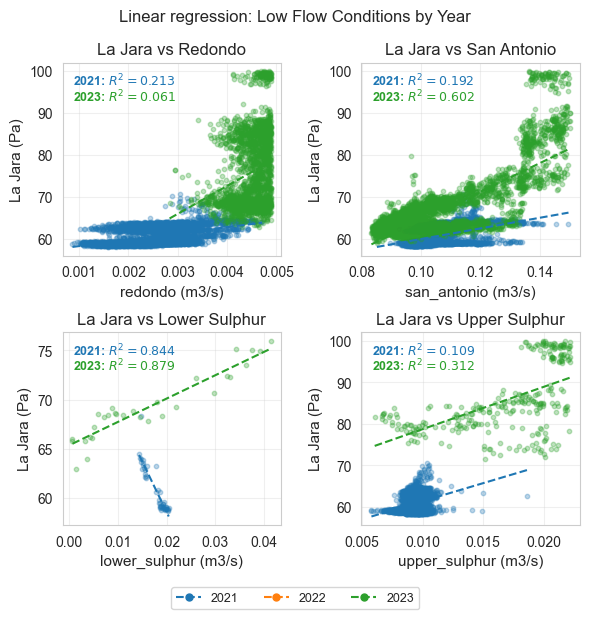

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Linear regression: Low Flow Conditions by Year', fontsize=12)

pairs = [
    (merged_redondo, 'redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    (merged_san_antonio, 'san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    (merged_lower_sulphur, 'lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    (merged_upper_sulphur, 'upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

colors = {'2021': '#1f77b4', '2022': '#ff7f0e', '2023': '#2ca02c'}

for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, 'la_jara']].dropna()
    valid_data = valid_data[valid_data['la_jara'] <= 100]
    valid_data = valid_data[valid_data['la_jara'] >= 58]

    y_position = 0.95

    for year, color in colors.items():
        year_data = valid_data[valid_data.index.year == int(year)]

        # exclude 2023 data before July 1
        #if year == '2023':
        #    year_data = year_data[year_data.index >= pd.Timestamp('2023-06-15')]
        # exclude 2022 data 
        if year == '2022':
            year_data = year_data[year_data.index < pd.Timestamp('2022-01-01')]

        if len(year_data) < 2:
            continue

        ax.scatter(year_data[x_col], year_data['la_jara'], alpha=0.3, s=10, color=color, label=year)

        slope, intercept, r_value, p_value, std_err = linregress(year_data[x_col], year_data['la_jara'])
        r2 = r_value**2

        x_line = np.array([year_data[x_col].min(), year_data[x_col].max()])
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, color=color, linestyle='--', linewidth=1.5)

        ax.text(
            0.05, y_position, f'{year}: $R^2 = {r2:.3f}$',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            color=color, weight='bold'
        )
        y_position -= 0.08

    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (Pa)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)

handles = [plt.Line2D([0], [0], color=color, marker='o', linestyle='--', linewidth=1.5, markersize=5, label=year) for year, color in colors.items()]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

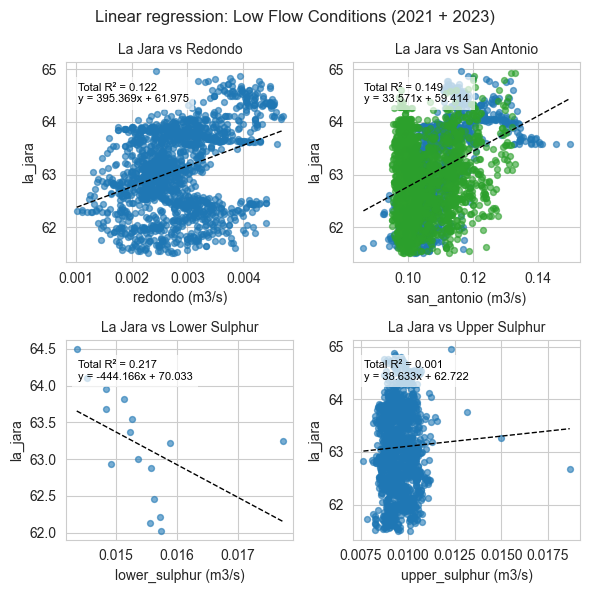

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle("Linear regression: Low Flow Conditions (2021 + 2023)", fontsize=12)

pairs = [
    (merged_redondo, "redondo (m3/s)", axes[0, 0], "La Jara vs Redondo"),
    (merged_san_antonio, "san_antonio (m3/s)", axes[0, 1], "La Jara vs San Antonio"),
    (merged_lower_sulphur, "lower_sulphur (m3/s)", axes[1, 0], "La Jara vs Lower Sulphur"),
    (merged_upper_sulphur, "upper_sulphur (m3/s)", axes[1, 1], "La Jara vs Upper Sulphur"),
]

colors = {"2021": "#1f77b4", "2022": "#ff7f0e", "2023": "#2ca02c"}  # blue, orange, green

for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, "la_jara"]].dropna()

    # Keep your low-flow filter
    valid_data = valid_data[
        (valid_data["la_jara"] <= 65) &
        (valid_data["la_jara"] > 61.5)
    ]

    year_subsets = []

    # Plot points by year (same style as before)
    for year, color in colors.items():
        year_data = valid_data[valid_data.index.year == int(year)]

        # Keep your 2023 start-date cutoff
        if year == "2023":
            year_data = year_data[year_data.index >= "2023-08-25"]
        if year == '2022':
            year_data = year_data[year_data.index < pd.Timestamp('2022-01-01')]

        if len(year_data) > 0:
            ax.scatter(
                year_data[x_col],
                year_data["la_jara"],
                alpha=0.6,
                s=18,
                color=color,
                label=year
            )
            year_subsets.append(year_data)

    # One combined fit across 2021 + filtered 2023
    if len(year_subsets) > 0:
        fit_data = pd.concat(year_subsets)

        if len(fit_data) > 1:
            x = fit_data[x_col].values
            y = fit_data["la_jara"].values

            slope, intercept, r_value, _, _ = linregress(x, y)
            x_line = np.linspace(x.min(), x.max(), 80)
            y_line = slope * x_line + intercept

            # Single total regression line
            ax.plot(x_line, y_line, color="black", linestyle="--", linewidth=1, label="Total fit (2021+2023)")
            ax.text(
                0.05, 0.8,
                f"Total R² = {r_value**2:.3f}\n"
                f"y = {slope:.3f}x + {intercept:.3f}",
                transform=ax.transAxes,
                fontsize=8,
                color="black",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
            )

    ax.set_title(title, fontsize=10)
    ax.set_xlabel(x_col)
    ax.set_ylabel("la_jara")

plt.tight_layout()
plt.show()

Power Law

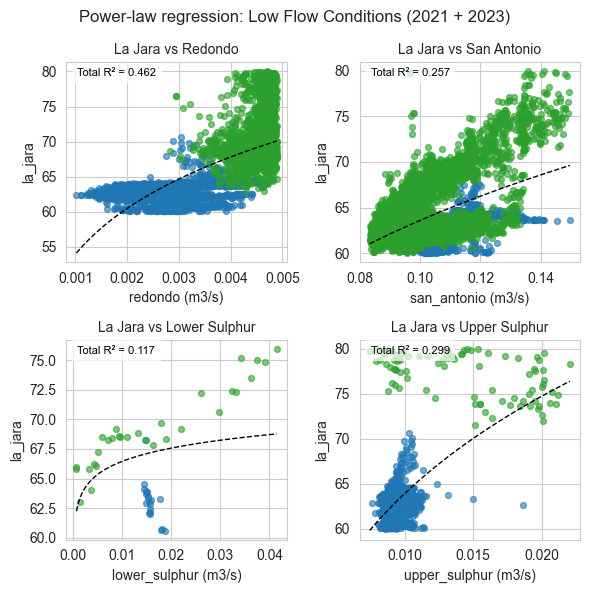

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle("Power-law regression: Low Flow Conditions (2021 + 2023)", fontsize=12)

pairs = [
    (merged_redondo, "redondo (m3/s)", axes[0, 0], "La Jara vs Redondo"),
    (merged_san_antonio, "san_antonio (m3/s)", axes[0, 1], "La Jara vs San Antonio"),
    (merged_lower_sulphur, "lower_sulphur (m3/s)", axes[1, 0], "La Jara vs Lower Sulphur"),
    (merged_upper_sulphur, "upper_sulphur (m3/s)", axes[1, 1], "La Jara vs Upper Sulphur"),
]

colors = {"2021": "#1f77b4", "2023": "#2ca02c"}  # blue, green

for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, "la_jara"]].dropna()

    # low-flow filter
    valid_data = valid_data[
        (valid_data["la_jara"] <= 80) &
        (valid_data["la_jara"] >= 60)
    ]

    year_subsets = []

    # scatter by year
    for year, color in colors.items():
        year_data = valid_data[valid_data.index.year == int(year)]

        # optional 2023 cutoff
        # if year == "2023":
        #     year_data = year_data[year_data.index >= "2023-06-15"]

        if len(year_data) > 0:
            ax.scatter(
                year_data[x_col],
                year_data["la_jara"],
                alpha=0.6,
                s=18,
                color=color,
                label=year
            )
            year_subsets.append(year_data)

    # combined power-law fit (2021 + 2023)
    if len(year_subsets) > 0:
        fit_data = pd.concat(year_subsets)

        # power law requires x > 0 and y > 0
        fit_data = fit_data[(fit_data[x_col] > 0) & (fit_data["la_jara"] > 0)]

        if len(fit_data) > 1:
            x = fit_data[x_col].values
            y = fit_data["la_jara"].values

            try:
                popt, _ = curve_fit(power_law, x, y, p0=[0.01, 0.1], maxfev=5000)

                y_pred = power_law(x, *popt)
                residuals = y - y_pred
                ss_res = np.sum(residuals**2)
                ss_tot = np.sum((y - np.mean(y))**2)
                r2 = 1 - (ss_res / ss_tot)

                x_line = np.linspace(x.min(), x.max(), 80)
                y_line = power_law(x_line, *popt)

                ax.plot(
                    x_line, y_line,
                    color="black", linestyle="--", linewidth=1.0,
                    label="Total fit (2021+2023)"
                )
                ax.text(
                    0.05, 0.93,
                    f"Total R² = {r2:.3f}",
                    transform=ax.transAxes,
                    fontsize=8,
                    color="black",
                    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
                )
            except Exception:
                ax.text(
                    0.05, 0.93,
                    "Power-law fit failed",
                    transform=ax.transAxes,
                    fontsize=8,
                    color="black",
                    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
                )

    ax.set_title(title, fontsize=10)
    ax.set_xlabel(x_col)
    ax.set_ylabel("la_jara")

plt.tight_layout()
plt.show()

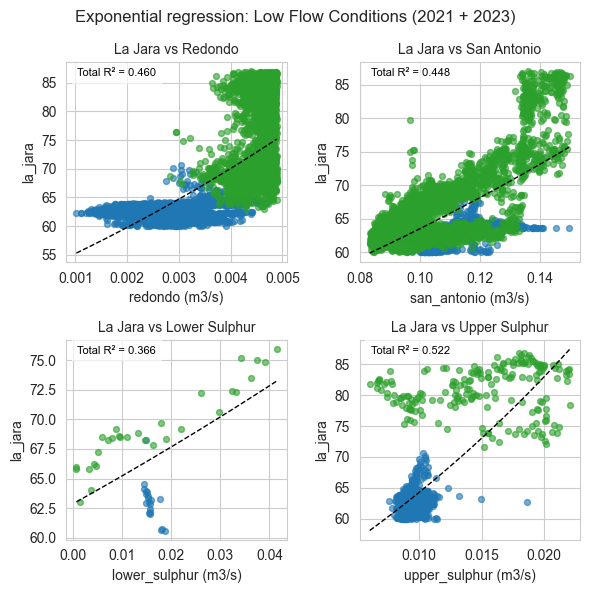

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle("Exponential regression: Low Flow Conditions (2021 + 2023)", fontsize=12)

pairs = [
    (merged_redondo, "redondo (m3/s)", axes[0, 0], "La Jara vs Redondo"),
    (merged_san_antonio, "san_antonio (m3/s)", axes[0, 1], "La Jara vs San Antonio"),
    (merged_lower_sulphur, "lower_sulphur (m3/s)", axes[1, 0], "La Jara vs Lower Sulphur"),
    (merged_upper_sulphur, "upper_sulphur (m3/s)", axes[1, 1], "La Jara vs Upper Sulphur"),
]

colors = {"2021": "#1f77b4", "2023": "#2ca02c"}  # blue, green

for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, "la_jara"]].dropna()

    # low-flow filter
    valid_data = valid_data[
        (valid_data["la_jara"] <= 87) &
        (valid_data["la_jara"] >= 60)
    ]

    year_subsets = []

    # scatter by year
    for year, color in colors.items():
        year_data = valid_data[valid_data.index.year == int(year)]

        # optional 2023 cutoff
        # if year == "2023":
        #     year_data = year_data[year_data.index >= "2023-06-15"]

        if len(year_data) > 0:
            ax.scatter(
                year_data[x_col],
                year_data["la_jara"],
                alpha=0.6,
                s=18,
                color=color,
                label=year
            )
            year_subsets.append(year_data)

    # combined exponential fit (2021 + 2023)
    if len(year_subsets) > 0:
        fit_data = pd.concat(year_subsets)

        # exponential fit requires x > 0 and y > 0
        fit_data = fit_data[(fit_data[x_col] > 0) & (fit_data["la_jara"] > 0)]

        if len(fit_data) > 1:
            x = fit_data[x_col].values
            y = fit_data["la_jara"].values

            try:
                popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)

                y_pred = exponential(x, *popt)
                residuals = y - y_pred
                ss_res = np.sum(residuals**2)
                ss_tot = np.sum((y - np.mean(y))**2)
                r2 = 1 - (ss_res / ss_tot)

                x_line = np.linspace(x.min(), x.max(), 80)
                y_line = exponential(x_line, *popt)

                ax.plot(
                    x_line, y_line,
                    color="black", linestyle="--", linewidth=1.0,
                    label="Total fit (2021+2023)"
                )
                ax.text(
                    0.05, 0.93,
                    f"Total R² = {r2:.3f}",
                    transform=ax.transAxes,
                    fontsize=8,
                    color="black",
                    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
                )
            except Exception:
                ax.text(
                    0.05, 0.93,
                    "Exponential fit failed",
                    transform=ax.transAxes,
                    fontsize=8,
                    color="black",
                    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
                )

    ax.set_title(title, fontsize=10)
    ax.set_xlabel(x_col)
    ax.set_ylabel("la_jara")

plt.tight_layout()
plt.show()

# Final

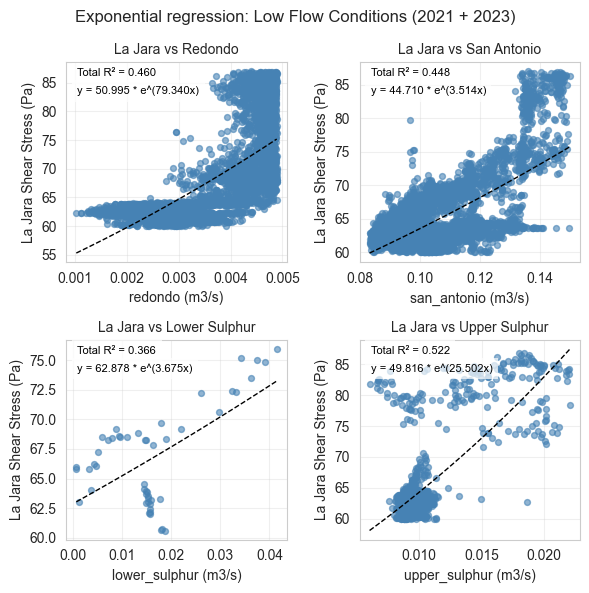

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle("Exponential regression: Low Flow Conditions (2021 + 2023)", fontsize=12)

pairs = [
    (merged_redondo, "redondo (m3/s)", axes[0, 0], "La Jara vs Redondo"),
    (merged_san_antonio, "san_antonio (m3/s)", axes[0, 1], "La Jara vs San Antonio"),
    (merged_lower_sulphur, "lower_sulphur (m3/s)", axes[1, 0], "La Jara vs Lower Sulphur"),
    (merged_upper_sulphur, "upper_sulphur (m3/s)", axes[1, 1], "La Jara vs Upper Sulphur"),
]

for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, "la_jara"]].dropna()

    # keep only 2021 + 2023 (no visual separation by year)
    valid_data = valid_data[valid_data.index.year.isin([2021, 2023])]

    # low-flow filter
    valid_data = valid_data[
        (valid_data["la_jara"] <= 87) &
        (valid_data["la_jara"] >= 60)
    ]

    # exponential fit requires x > 0 and y > 0
    fit_data = valid_data[(valid_data[x_col] > 0) & (valid_data["la_jara"] > 0)]

    # one scatter style for all points
    ax.scatter(
        fit_data[x_col],
        fit_data["la_jara"],
        alpha=0.6,
        s=18,
        color="steelblue"
    )

    if len(fit_data) > 1:
        x = fit_data[x_col].values
        y = fit_data["la_jara"].values

        try:
            popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)

            y_pred = exponential(x, *popt)
            residuals = y - y_pred
            ss_res = np.sum(residuals**2)
            ss_tot = np.sum((y - np.mean(y))**2)
            r2 = 1 - (ss_res / ss_tot)

            x_line = np.linspace(x.min(), x.max(), 80)
            y_line = exponential(x_line, *popt)
            ax.plot(x_line, y_line, color="black", linestyle="--", linewidth=1.0)

            # equation text
            eq_text = f"y = {popt[0]:.3f} * e^({popt[1]:.3f}x)"

            ax.text(
                0.05, 0.93,
                f"Total R² = {r2:.3f}",
                transform=ax.transAxes,
                fontsize=8,
                color="black",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
            )
            ax.text(
                0.05, 0.84,
                eq_text,
                transform=ax.transAxes,
                fontsize=8,
                color="black",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
            )
        except Exception:
            ax.text(
                0.05, 0.93,
                "Exponential fit failed",
                transform=ax.transAxes,
                fontsize=8,
                color="black",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
            )

    ax.set_title(title, fontsize=10)
    ax.set_xlabel(x_col)
    ax.set_ylabel("La Jara Shear Stress (Pa)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show() 